# 03: Graph Neural Network - GraphSAGE
**Project:** Robust Financial Fraud Detection using GNNs and Multimodal Fusion
**Author:** Israt Islam | 23082056 | University of Hertfordshire
**Purpose:** Construct a transaction graph, train GraphSAGE to detect fraud rings, evaluate standalone performance, and save 64-dim node embeddings for Notebook 04.

---
### Why Graph Neural Networks?
Traditional ML treats each transaction independently. Fraudsters reuse cards, emails, and addresses — creating detectable **fraud rings**. GraphSAGE aggregates neighbourhood information to detect these relational patterns.

## 1. Install PyTorch Geometric
PyTorch Geometric (PyG) is the standard library for graph neural networks in PyTorch. We install a specific version for compatibility.

In [1]:
import torch
print(f'PyTorch: {torch.__version__}')
print(f'CUDA:    {torch.cuda.is_available()}')

# Install PyTorch Geometric (specific version for compatibility)
!pip install torch-geometric==2.5.3 -q

# Verify installation
import torch_geometric
from torch_geometric.nn import SAGEConv
print(f'PyG: {torch_geometric.__version__}')
print('Installation complete.')

PyTorch: 2.10.0+cu128
CUDA:    True
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.2/64.2 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 29.0 MB/s eta 0:00:00
PyG: 2.5.3
Installation complete.


## 2. Setup and Load Data
Mount Drive, import all libraries, set device to GPU, define helper functions, and load processed data.

In [2]:
# ── Mount Google Drive ────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
BASE = '/content/drive/MyDrive/FraudProject'

# ── Imports ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx   # for graph visualisation
import warnings, gc, os
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score,
    recall_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve
)
from sklearn.preprocessing import StandardScaler

# ── Set device (use GPU if available) ────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

sns.set_style('darkgrid')
plt.rcParams['figure.dpi'] = 100

def savefig(name):
    """
    Save current matplotlib figure to /figures/ at 300dpi (thesis quality).

    Args:
        name (str): Filename without extension
    """
    plt.savefig(f'{BASE}/figures/{name}.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  Saved -> figures/{name}.png')

# ── Load processed data ───────────────────────────────────────────────────────
print('Loading data...')
X_train = pd.read_parquet(f'{BASE}/processed/X_train.parquet')
X_test  = pd.read_parquet(f'{BASE}/processed/X_test.parquet')
y_train = np.load(f'{BASE}/processed/y_train.npy')
y_test  = np.load(f'{BASE}/processed/y_test.npy')

# Full dataset needed for graph construction (maintains time order)
df_full = pd.read_parquet(f'{BASE}/processed/train_processed.parquet')

# Clean infinite values
for frame in [X_train, X_test]:
    frame.replace([np.inf, -np.inf], np.nan, inplace=True)
    frame.fillna(0, inplace=True)

print(f'X_train: {X_train.shape}')
print(f'X_test:  {X_test.shape}')
print(f'Full df: {df_full.shape}')

Mounted at /content/drive
Device: cuda
Loading data...
X_train: (472432, 365)
X_test:  (118108, 365)
Full df: (590540, 367)


## 3. Build Transaction Graph
Nodes = transactions, Edges = shared card/address. We use card1 (0% null), card2 (1.5% null), addr1 (11.1% null). DeviceInfo excluded due to 79.9% nulls.

In [3]:
print('Building transaction graph...')
print('Using card1, card2, addr1 (low null columns)')

# ── Sort transactions by time (same order as train/test split) ────────────────
df_sorted = df_full.sort_values('TransactionDT').reset_index(drop=True)
n_nodes   = len(df_sorted)      # one node per transaction
split_idx = int(n_nodes * 0.80)  # same 80/20 split as training

# ── Edge lists ────────────────────────────────────────────────────────────────
edge_sources = []  # source node indices
edge_targets = []  # target node indices

def add_edges_from_column(col, max_group_size=30):
    """
    Add edges between transactions that share the same value in a column.
    Connects consecutive pairs within each group to avoid dense hubs.

    Args:
        col (str):           Column name to group by (e.g. 'card1')
        max_group_size (int): Cap group size to avoid memory explosion
    """
    # Fill nulls so they don't create false connections between unrelated rows
    temp   = df_sorted[col].fillna('MISSING_VALUE')
    groups = temp.groupby(temp).groups
    count  = 0

    for val, idx_list in groups.items():
        # Skip null group — missing values should not create edges
        if val == 'MISSING_VALUE':
            continue

        idx_list = list(idx_list)

        # Need at least 2 transactions to form an edge
        if len(idx_list) < 2:
            continue

        # Cap group size to prevent memory explosion on common cards
        if len(idx_list) > max_group_size:
            idx_list = idx_list[:max_group_size]

        # Connect consecutive transaction pairs within the group
        for i in range(len(idx_list) - 1):
            # Add edge in both directions (undirected graph)
            edge_sources.append(idx_list[i])
            edge_targets.append(idx_list[i+1])
            edge_sources.append(idx_list[i+1])
            edge_targets.append(idx_list[i])
            count += 1

    print(f'  {col}: {count:,} edges added')

# ── Add edges from each shared attribute ──────────────────────────────────────
add_edges_from_column('card1')  # 0% nulls   — most reliable
add_edges_from_column('card2')  # 1.5% nulls — very reliable
add_edges_from_column('addr1')  # 11.1% nulls — acceptable

print(f'\nGraph statistics:')
print(f'  Total nodes:  {n_nodes:,}')
print(f'  Total edges:  {len(edge_sources):,}')
print(f'  Avg degree:   {len(edge_sources)/n_nodes:.2f}')

Building transaction graph...
Using card1, card2, addr1 (low null columns)
  card1: 112,002 edges added
  card2: 14,472 edges added
  addr1: 2,930 edges added

Graph statistics:
  Total nodes:  590,540
  Total edges:  258,808
  Avg degree:   0.44


## 4. Graph Statistics Visualisation
Degree distribution and fraud vs legitimate connectivity patterns reveal the graph structure.

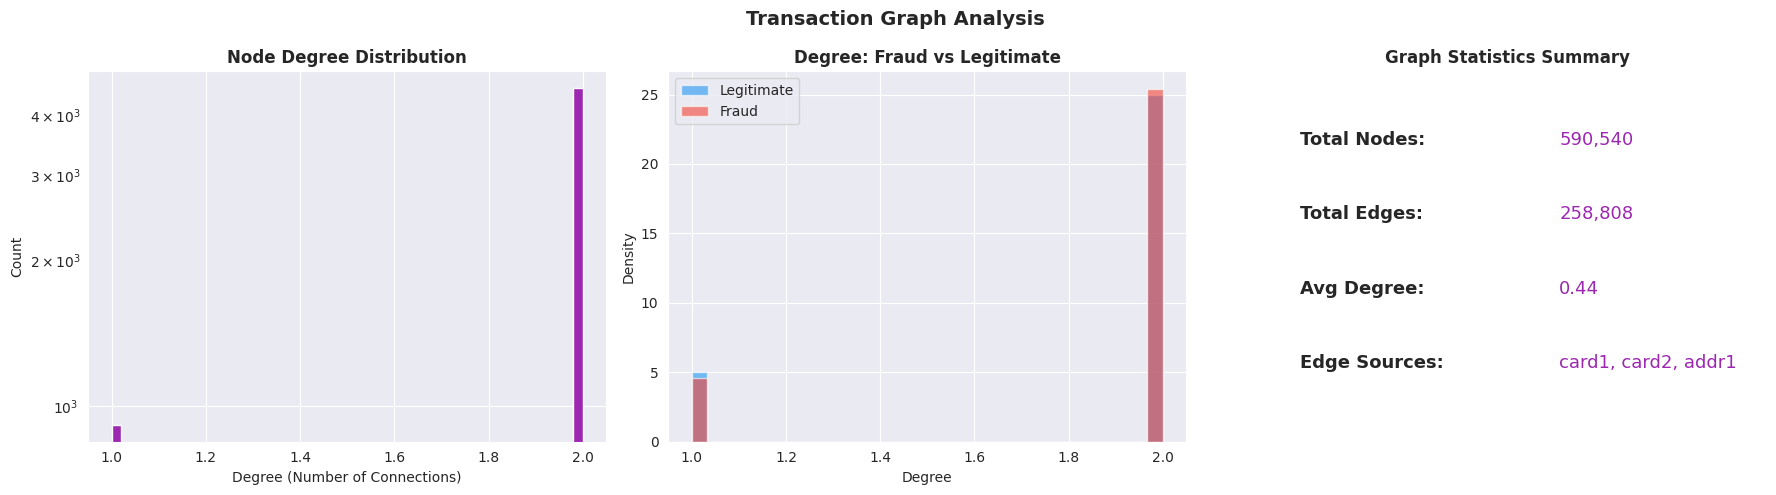

  Saved -> figures/17_graph_statistics.png


In [4]:
# ── Build sample graph for visualisation (full graph too large) ───────────────
G_sample     = nx.Graph()
sample_edges = list(zip(edge_sources[:10000], edge_targets[:10000]))
G_sample.add_edges_from(sample_edges)
degrees      = [d for n, d in G_sample.degree()]
node_labels  = df_sorted['isFraud'].values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Degree distribution histogram ────────────────────────────────────────────
axes[0].hist(degrees, bins=50, color='#9C27B0', edgecolor='white')
axes[0].set_title('Node Degree Distribution', fontweight='bold')
axes[0].set_xlabel('Degree (Number of Connections)')
axes[0].set_ylabel('Count')
axes[0].set_yscale('log')  # log scale to show full range

# ── Fraud vs legit degree comparison ─────────────────────────────────────────
# If fraud nodes have higher degree, it suggests they are in dense clusters
fraud_degrees = [G_sample.degree(n) for n in G_sample.nodes()
                 if n < len(node_labels) and node_labels[n]==1]
legit_degrees = [G_sample.degree(n) for n in G_sample.nodes()
                 if n < len(node_labels) and node_labels[n]==0]
axes[1].hist(legit_degrees, bins=30, alpha=0.6, color='#2196F3',
             label='Legitimate', density=True)
axes[1].hist(fraud_degrees, bins=30, alpha=0.6, color='#F44336',
             label='Fraud', density=True)
axes[1].set_title('Degree: Fraud vs Legitimate', fontweight='bold')
axes[1].set_xlabel('Degree')
axes[1].set_ylabel('Density')
axes[1].legend()

# ── Graph summary statistics text panel ──────────────────────────────────────
stats = {
    'Total Nodes':  f'{n_nodes:,}',
    'Total Edges':  f'{len(edge_sources):,}',
    'Avg Degree':   f'{len(edge_sources)/n_nodes:.2f}',
    'Edge Sources': 'card1, card2, addr1'
}
axes[2].axis('off')
y_pos = 0.8
for key, val in stats.items():
    axes[2].text(0.1, y_pos, f'{key}:', fontsize=13,
                 fontweight='bold', transform=axes[2].transAxes)
    axes[2].text(0.6, y_pos, val, fontsize=13,
                 color='#9C27B0', transform=axes[2].transAxes)
    y_pos -= 0.2
axes[2].set_title('Graph Statistics Summary', fontweight='bold')

plt.suptitle('Transaction Graph Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
savefig('17_graph_statistics')

## 5. Fraud Ring Visualisation
Visualize connected fraud transactions to demonstrate the graph's ability to detect fraud rings — the key motivation for using GNNs.

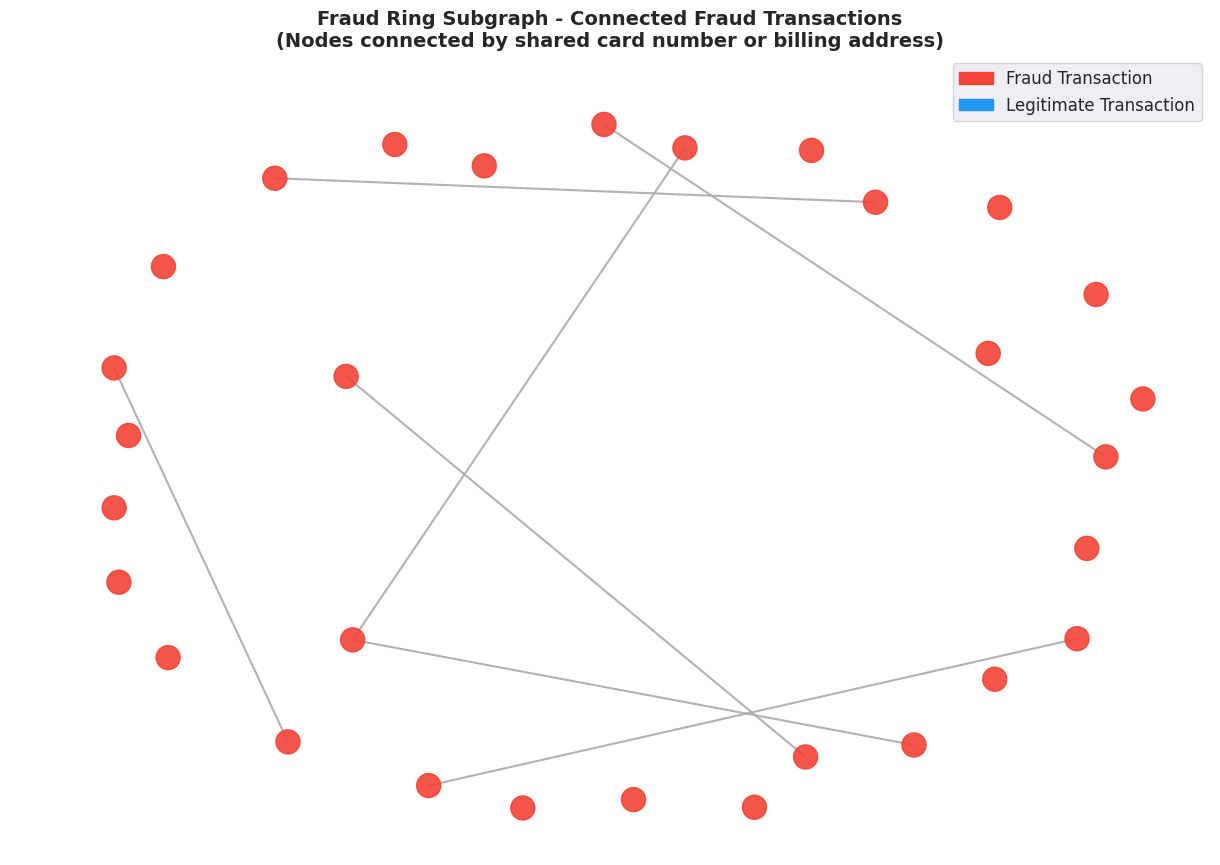

  Saved -> figures/18_fraud_subgraph.png
Subgraph: 30 nodes, 7 edges


In [5]:
# ── Find connected fraud nodes ────────────────────────────────────────────────
fraud_indices   = set(np.where(node_labels == 1)[0])
connected_fraud = []

# Search first 50k edges for fraud-fraud connections
for src, tgt in zip(edge_sources[:50000], edge_targets[:50000]):
    if src in fraud_indices and tgt in fraud_indices:
        connected_fraud.extend([src, tgt])

connected_fraud = list(set(connected_fraud))[:30]  # take up to 30 nodes

if len(connected_fraud) > 3:
    # ── Build fraud subgraph ──────────────────────────────────────────────────
    G_sub = nx.Graph()
    for src, tgt in zip(edge_sources, edge_targets):
        if src in connected_fraud and tgt in connected_fraud:
            G_sub.add_edge(src, tgt)
    for n in connected_fraud:
        G_sub.add_node(n)  # add isolated nodes too

    # ── Colour nodes by fraud status ──────────────────────────────────────────
    node_colors = ['#F44336' if node_labels[n]==1 else '#2196F3'
                   for n in G_sub.nodes()]

    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(G_sub, seed=42, k=2)  # spring layout for clear separation
    nx.draw(
        G_sub, pos,
        node_color=node_colors,
        node_size=300,
        edge_color='#aaaaaa',
        width=1.5,
        with_labels=False,
        alpha=0.9
    )

    # Legend
    fraud_patch = mpatches.Patch(color='#F44336', label='Fraud Transaction')
    legit_patch = mpatches.Patch(color='#2196F3', label='Legitimate Transaction')
    plt.legend(handles=[fraud_patch, legit_patch], fontsize=12)
    plt.title(
        'Fraud Ring Subgraph - Connected Fraud Transactions\n'
        '(Nodes connected by shared card number or billing address)',
        fontsize=14, fontweight='bold'
    )
    savefig('18_fraud_subgraph')
    print(f'Subgraph: {G_sub.number_of_nodes()} nodes, {G_sub.number_of_edges()} edges')

## 6. Create PyTorch Geometric Data Object
Convert graph to PyG format. Scale node features — critical for GNN performance since neighbourhood aggregation is sensitive to feature magnitude.

In [6]:
print('Creating PyG Data object...')

# ── Combine train + test in time order ───────────────────────────────────────
X_all = pd.concat([X_train, X_test], axis=0).reset_index(drop=True)
X_all.replace([np.inf, -np.inf], np.nan, inplace=True)
X_all.fillna(0, inplace=True)
y_all = np.concatenate([y_train, y_test])

# ── Scale features (essential for GNN convergence) ───────────────────────────
# GNNs aggregate neighbour features — unscaled features cause training instability
sc           = StandardScaler()
X_all_scaled = sc.fit_transform(X_all)

# ── Convert to PyTorch tensors ────────────────────────────────────────────────
x          = torch.tensor(X_all_scaled, dtype=torch.float)             # node features
edge_index = torch.tensor([edge_sources, edge_targets], dtype=torch.long)  # graph edges
y          = torch.tensor(y_all, dtype=torch.float)                    # labels

# ── Create train/test masks ───────────────────────────────────────────────────
# Masks indicate which nodes belong to train vs test set
train_mask = torch.zeros(n_nodes, dtype=torch.bool)
test_mask  = torch.zeros(n_nodes, dtype=torch.bool)
train_mask[:split_idx] = True   # first 80% of time = training
test_mask[split_idx:]  = True   # last  20% of time = testing

# ── Create PyG Data object and move to GPU ────────────────────────────────────
data = Data(x=x, edge_index=edge_index, y=y,
            train_mask=train_mask, test_mask=test_mask)
data = data.to(DEVICE)

print(f'Nodes:       {data.num_nodes:,}')
print(f'Edges:       {data.num_edges:,}')
print(f'Features:    {data.num_node_features}')
print(f'Train nodes: {train_mask.sum():,}')
print(f'Test nodes:  {test_mask.sum():,}')
print(f'Device:      {data.x.device}')

Creating PyG Data object...
Nodes:       590,540
Edges:       258,808
Features:    365
Train nodes: 472,432
Test nodes:  118,108
Device:      cuda:0


## 7. Define GraphSAGE Model
GraphSAGE (Hamilton et al., 2017) learns by sampling and aggregating neighbourhood features. 2-layer architecture: input → 128-dim → 64-dim embedding → fraud probability.

In [7]:
class GraphSAGE(nn.Module):
    """
    2-layer GraphSAGE model for fraud detection.

    Architecture:
        Input features -> SAGEConv(128) -> ReLU -> Dropout
        -> SAGEConv(64) -> Linear(1) -> Sigmoid

    The 64-dim intermediate embeddings are saved for multimodal fusion.

    Args:
        in_channels (int):  Number of input node features
        hidden (int):       Hidden layer dimension (default: 128)
        embed_dim (int):    Output embedding dimension (default: 64)
        dropout (float):    Dropout probability (default: 0.3)
    """
    def __init__(self, in_channels, hidden=128, embed_dim=64, dropout=0.3):
        super().__init__()

        # Layer 1: input features -> hidden representation
        self.conv1 = SAGEConv(in_channels, hidden)

        # Layer 2: hidden -> embedding (saved for fusion)
        self.conv2 = SAGEConv(hidden, embed_dim)

        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(embed_dim, 1)  # final fraud probability

    def encode(self, x, edge_index):
        """
        Compute node embeddings without classification head.
        Used to extract embeddings for multimodal fusion.

        Returns:
            torch.Tensor: 64-dim node embeddings
        """
        x = F.relu(self.conv1(x, edge_index))
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x

    def forward(self, x, edge_index):
        """
        Forward pass: compute embeddings and fraud probabilities.

        Returns:
            tuple: (logits, embeddings)
        """
        emb = self.encode(x, edge_index)        # 64-dim embeddings
        out = self.classifier(emb).squeeze()    # fraud logits
        return out, emb


# ── Instantiate model ─────────────────────────────────────────────────────────
model  = GraphSAGE(in_channels=data.num_node_features).to(DEVICE)
total  = sum(p.numel() for p in model.parameters())
print(model)
print(f'Total parameters: {total:,}')

GraphSAGE(
  (conv1): SAGEConv(365, 128, aggr=mean)
  (conv2): SAGEConv(128, 64, aggr=mean)
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=64, out_features=1, bias=True)
)
Total parameters: 110,081


## 8. Training Setup
Weighted BCE loss for 48/52 balance. Adam optimiser with learning rate scheduler.

In [8]:
# ── Compute pos_weight for weighted BCE loss ──────────────────────────────────
# pos_weight = (target_fraud_proportion / n_fraud) / (target_legit_proportion / n_legit)
# This reweights the loss so fraud cases contribute 48% of total gradient
TARGET_FRAUD  = 0.48
TARGET_LEGIT  = 0.52
n_fraud_train = int(train_mask.sum().item() * y_all[:split_idx].mean())
n_legit_train = int(train_mask.sum().item()) - n_fraud_train

pos_weight = torch.tensor(
    [(TARGET_FRAUD/n_fraud_train) / (TARGET_LEGIT/n_legit_train)]
).to(DEVICE)

# ── Loss, optimiser, scheduler ────────────────────────────────────────────────
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Adam with weight decay (L2 regularisation) to prevent overfitting
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# Reduce learning rate when validation AUC stops improving
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=10, factor=0.5
)

print(f'pos_weight:  {pos_weight.item():.4f}')
print(f'Loss:        BCEWithLogitsLoss (weighted for 48/52 balance)')
print(f'Optimizer:   Adam (lr=0.001, weight_decay=1e-4)')
print(f'Scheduler:   ReduceLROnPlateau (patience=10, factor=0.5)')

pos_weight:  25.3491
Loss:        BCEWithLogitsLoss (weighted for 48/52 balance)
Optimizer:   Adam (lr=0.001, weight_decay=1e-4)
Scheduler:   ReduceLROnPlateau (patience=10, factor=0.5)


## 9. Train GraphSAGE (100 Epochs)
Train for 100 epochs, save best checkpoint based on validation AUC.

In [9]:
EPOCHS             = 100
train_losses       = []   # track training loss per epoch
test_aucs          = []   # track validation AUC per epoch
best_auc, best_ep  = 0.0, 0

print(f'Training GraphSAGE for {EPOCHS} epochs on {DEVICE}...')
print('-'*55)

for epoch in range(1, EPOCHS+1):

    # ── Training step ─────────────────────────────────────────────────────────
    model.train()
    optimizer.zero_grad()

    # Forward pass: compute logits for all nodes
    out, _ = model(data.x, data.edge_index)

    # Compute loss only on training nodes (not test nodes)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    # ── Validation step ───────────────────────────────────────────────────────
    model.eval()
    with torch.no_grad():  # disable gradient computation for efficiency
        out_eval, _ = model(data.x, data.edge_index)

        # Get predictions for test nodes only
        probs  = torch.sigmoid(out_eval[data.test_mask]).cpu().numpy()
        labels = data.y[data.test_mask].cpu().numpy()
        auc    = roc_auc_score(labels, probs)
        test_aucs.append(auc)

    # ── Learning rate scheduling ──────────────────────────────────────────────
    scheduler.step(auc)

    # ── Save best model checkpoint ────────────────────────────────────────────
    if auc > best_auc:
        best_auc, best_ep = auc, epoch
        torch.save(model.state_dict(), f'{BASE}/models/graphsage_best.pt')

    # ── Progress logging ──────────────────────────────────────────────────────
    if epoch % 10 == 0:
        print(f'  Epoch {epoch:3d}/{EPOCHS} | '
              f'Loss: {loss.item():.4f} | '
              f'AUC: {auc:.4f} | '
              f'Best: {best_auc:.4f} (ep {best_ep})')

print(f'\nTraining complete!')
print(f'Best AUC: {best_auc:.4f} at epoch {best_ep}')

Training GraphSAGE for 100 epochs on cuda...
-------------------------------------------------------
  Epoch  10/100 | Loss: 1.0096 | AUC: 0.7983 | Best: 0.7983 (ep 10)
  Epoch  20/100 | Loss: 0.9277 | AUC: 0.8154 | Best: 0.8154 (ep 20)
  Epoch  30/100 | Loss: 0.8798 | AUC: 0.8257 | Best: 0.8257 (ep 30)
  Epoch  40/100 | Loss: 0.8449 | AUC: 0.8335 | Best: 0.8335 (ep 40)
  Epoch  50/100 | Loss: 0.8186 | AUC: 0.8358 | Best: 0.8358 (ep 50)
  Epoch  60/100 | Loss: 0.7950 | AUC: 0.8396 | Best: 0.8396 (ep 60)
  Epoch  70/100 | Loss: 0.7756 | AUC: 0.8437 | Best: 0.8437 (ep 70)
  Epoch  80/100 | Loss: 0.7563 | AUC: 0.8480 | Best: 0.8480 (ep 80)
  Epoch  90/100 | Loss: 0.7326 | AUC: 0.8508 | Best: 0.8508 (ep 90)
  Epoch 100/100 | Loss: 0.7155 | AUC: 0.8551 | Best: 0.8551 (ep 100)

Training complete!
Best AUC: 0.8551 at epoch 100


## 10. Training Curves
Plot loss and AUC per epoch to confirm learning and check for overfitting.

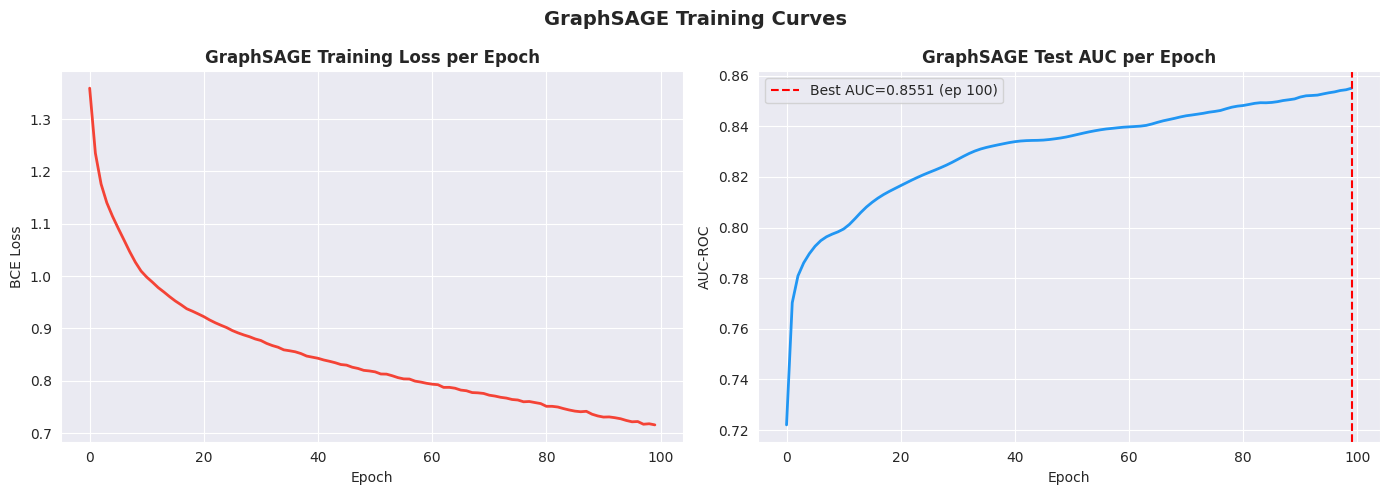

  Saved -> figures/19_gnn_training_curves.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Training loss curve ───────────────────────────────────────────────────────
axes[0].plot(train_losses, color='#F44336', linewidth=2)
axes[0].set_title('GraphSAGE Training Loss per Epoch', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('BCE Loss')

# ── Validation AUC curve ──────────────────────────────────────────────────────
axes[1].plot(test_aucs, color='#2196F3', linewidth=2)
axes[1].axvline(
    best_ep-1, color='red', linestyle='--',
    label=f'Best AUC={best_auc:.4f} (ep {best_ep})'  # mark best checkpoint
)
axes[1].set_title('GraphSAGE Test AUC per Epoch', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC-ROC')
axes[1].legend()

plt.suptitle('GraphSAGE Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
savefig('19_gnn_training_curves')

## 11. Evaluate Best GraphSAGE Model
Load best checkpoint and compute all evaluation metrics on the test set.

In [11]:
# ── Load best checkpoint ──────────────────────────────────────────────────────
model.load_state_dict(torch.load(f'{BASE}/models/graphsage_best.pt'))
model.eval()

with torch.no_grad():
    out, embeddings = model(data.x, data.edge_index)

    # Get test node predictions
    gnn_probs = torch.sigmoid(out[data.test_mask]).cpu().numpy()
    gnn_preds = (gnn_probs >= 0.5).astype(int)  # convert probabilities to labels
    y_true    = data.y[data.test_mask].cpu().numpy()

# ── Compute all metrics ───────────────────────────────────────────────────────
tn, fp, fn, tp = confusion_matrix(y_true, gnn_preds).ravel()
fpr_val        = fp / (fp + tn)

gnn_metrics = {
    'Model':     'GraphSAGE',
    'AUC-ROC':   round(roc_auc_score(y_true, gnn_probs), 4),
    'F1':        round(f1_score(y_true, gnn_preds), 4),
    'Precision': round(precision_score(y_true, gnn_preds), 4),
    'Recall':    round(recall_score(y_true, gnn_preds), 4),
    'FPR':       round(fpr_val, 4),
    'TP': int(tp), 'FP': int(fp), 'TN': int(tn), 'FN': int(fn)
}

print('GraphSAGE Results (Best Checkpoint)')
print('='*50)
for k in ['AUC-ROC','F1','Precision','Recall','FPR']:
    print(f'  {k:10} {gnn_metrics[k]}')
print(f'  TP:{tp}  FP:{fp}  TN:{tn}  FN:{fn}')

GraphSAGE Results (Best Checkpoint)
  AUC-ROC    0.8551
  F1         0.1961
  Precision  0.1126
  Recall     0.7574
  FPR        0.2127
  TP:3078  FP:24253  TN:89791  FN:986


## 12. Compare GNN vs Baselines
Add GraphSAGE to the baseline results table and save the combined CSV.

In [12]:
import pandas as pd

# ── Load baseline results from NB02 ──────────────────────────────────────────
baseline_df = pd.read_csv(f'{BASE}/processed/results_baseline.csv', index_col='Model')

# ── Append GNN results ────────────────────────────────────────────────────────
gnn_row     = pd.DataFrame([gnn_metrics]).set_index('Model')
all_results = pd.concat([baseline_df, gnn_row])

cols = ['AUC-ROC','F1','Precision','Recall','FPR']
print('MODEL COMPARISON: Baselines vs GraphSAGE')
print('='*65)
print(all_results[cols].to_string())
print('='*65)
print(f"Best AUC:   {all_results['AUC-ROC'].idxmax()} ({all_results['AUC-ROC'].max()})")
print(f"Lowest FPR: {all_results['FPR'].idxmin()} ({all_results['FPR'].min()})")

# ── Save combined results ─────────────────────────────────────────────────────
all_results.to_csv(f'{BASE}/processed/results_with_gnn.csv')
print('\nSaved -> processed/results_with_gnn.csv')

MODEL COMPARISON: Baselines vs GraphSAGE
                     AUC-ROC      F1  Precision  Recall     FPR
Model                                                          
Logistic Regression   0.8306  0.1703     0.0959  0.7625  0.2563
Random Forest         0.8715  0.3207     0.2156  0.6257  0.0811
XGBoost               0.9127  0.3683     0.2486  0.7096  0.0764
LightGBM              0.9099  0.3506     0.2321  0.7160  0.0844
GraphSAGE             0.8551  0.1961     0.1126  0.7574  0.2127
Best AUC:   XGBoost (0.9127)
Lowest FPR: XGBoost (0.0764)

Saved -> processed/results_with_gnn.csv


## 13. ROC Curve: GNN vs Best Baseline

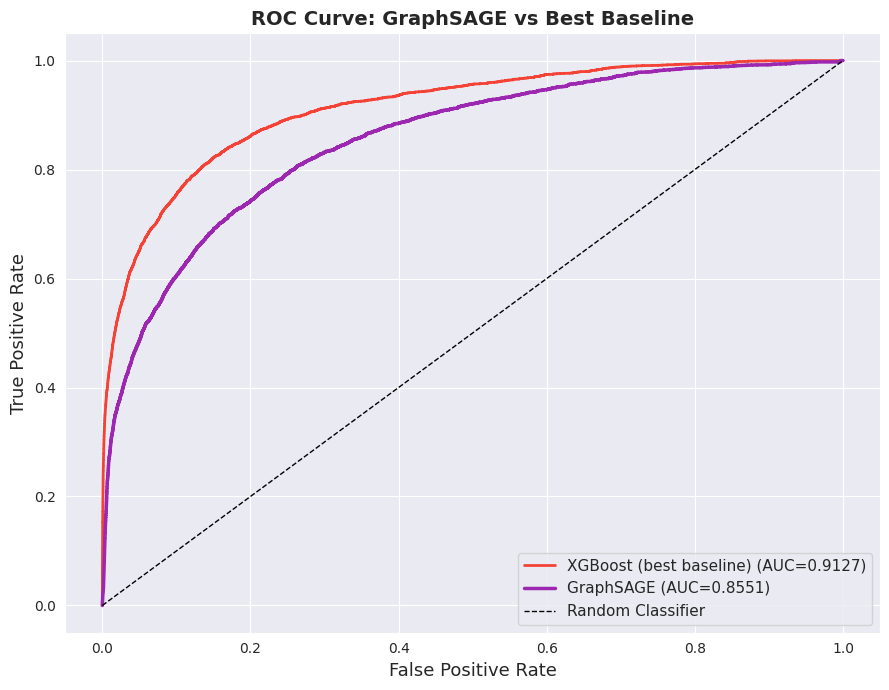

  Saved -> figures/20_roc_gnn_vs_baseline.png


In [13]:
import joblib

# ── Load XGBoost for comparison ───────────────────────────────────────────────
xgb               = joblib.load(f'{BASE}/models/xgb_model.pkl')
xgb_probs_compare = xgb.predict_proba(X_test.copy())[:, 1]

plt.figure(figsize=(9, 7))

# Plot ROC for XGBoost (best tabular baseline) vs GraphSAGE
for name, probs, labels, color, lw in [
    ('XGBoost (best baseline)', xgb_probs_compare, y_test,  '#F44336', 2),
    ('GraphSAGE',               gnn_probs,          y_true,  '#9C27B0', 2.5),
]:
    fpr_c, tpr_c, _ = roc_curve(labels, probs)
    auc = roc_auc_score(labels, probs)
    plt.plot(fpr_c, tpr_c,
             label=f'{name} (AUC={auc:.4f})',
             color=color, linewidth=lw)

plt.plot([0,1],[0,1],'k--', label='Random Classifier', linewidth=1)
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('ROC Curve: GraphSAGE vs Best Baseline', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
savefig('20_roc_gnn_vs_baseline')

## 14. Save Node Embeddings
Save 64-dim embeddings for ALL nodes. These are the graph branch input for the Multimodal Fusion model in NB04.

In [14]:
print('Saving 64-dim node embeddings for fusion...')

# ── Extract embeddings for all nodes ─────────────────────────────────────────
model.eval()
with torch.no_grad():
    _, all_embeddings = model(data.x, data.edge_index)
    all_embeddings    = all_embeddings.cpu().numpy()  # shape: (n_nodes, 64)

# ── Split back into train/test ────────────────────────────────────────────────
train_embeddings = all_embeddings[:split_idx]   # training node embeddings
test_embeddings  = all_embeddings[split_idx:]   # test node embeddings

# ── Save to disk ──────────────────────────────────────────────────────────────
np.save(f'{BASE}/processed/gnn_embeddings_train.npy', train_embeddings)
np.save(f'{BASE}/processed/gnn_embeddings_test.npy',  test_embeddings)

print(f'  Train embeddings: {train_embeddings.shape}  (one 64-dim vector per training transaction)')
print(f'  Test  embeddings: {test_embeddings.shape}   (one 64-dim vector per test transaction)')
print()
print('NOTEBOOK 03 COMPLETE')
print('Saved: graphsage_best.pt | gnn_embeddings_*.npy | results_with_gnn.csv')
print('Next -> 04_Multimodal_Fusion.ipynb')

Saving 64-dim node embeddings for fusion...
  Train embeddings: (472432, 64)  (one 64-dim vector per training transaction)
  Test  embeddings: (118108, 64)   (one 64-dim vector per test transaction)

NOTEBOOK 03 COMPLETE
Saved: graphsage_best.pt | gnn_embeddings_*.npy | results_with_gnn.csv
Next -> 04_Multimodal_Fusion.ipynb


---
## Notebook Summary

| Step | Description | Output |
|---|---|---|
| Graph Construction | Nodes=transactions, edges=card1/card2/addr1 | edge_index |
| Graph Statistics | Degree distribution, fraud connectivity | figures/17 |
| Fraud Ring | Visual of connected fraud cluster | figures/18 |
| GraphSAGE Training | 2-layer SAGEConv, 100 epochs | graphsage_best.pt |
| Evaluation | AUC, F1, FPR vs all baselines | results_with_gnn.csv |
| Embeddings | 64-dim per transaction | gnn_embeddings_*.npy |

**Next:** `04_Multimodal_Fusion.ipynb`